# Tutorial 03 (part 5): Generative Adversarial Networks with TensorFlow and Keras
By Prof Ivan Olier

## Introduction

The aim of this tutorial is to practise how to implement a simple **Generative Adversarial Network (GAN)** in TensorFlow/Keras. We will use a small subset of the MNIST handwritten digits dataset and train two neural networks together:

* a **generator**, which learns to create images that look like handwritten digits;
* a **discriminator**, which learns to distinguish real MNIST images from generated images.

The tutorial is intentionally small enough to run during a practical session. The images produced by this short run will not be perfect, but the notebook will help you understand the main components of a GAN training pipeline.

## Learning outcomes

By the end of this tutorial, you should be able to:

* explain the roles of the generator and discriminator in a GAN;
* prepare image data for GAN training;
* build a generator using dense, reshape and transposed-convolution layers;
* build a discriminator using convolutional layers;
* define generator and discriminator losses;
* train both networks using `tf.GradientTape`;
* inspect the evolution of generated images during training.

## Practical note

GANs can be slow and unstable to train. The default settings below are designed for a classroom demonstration. Better images usually require more data, more epochs, and careful tuning.


In [136]:
import glob
import os
import time

import imageio
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from IPython import display
from tensorflow.keras import layers

%matplotlib inline


For reproducibility, we set random seeds. This does not make every run exactly identical on every machine, but it reduces unnecessary variation.

We also print the TensorFlow version and whether a GPU is available. The notebook can run on a CPU, but training will be faster on a GPU.


In [137]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load and prepare the dataset

We will use the MNIST dataset, which contains 28 × 28 greyscale images of handwritten digits. In a full GAN exercise we could use all digits, but for a short teaching session we restrict the data to a few classes and a small number of images.

The generator does **not** receive the digit labels. The labels are only used here to select a smaller subset of the data.


In [138]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

print("Original training images:", train_images.shape)
print("Original training labels:", train_labels.shape)


Original training images: (60000, 28, 28)
Original training labels: (60000,)


We select only a few digits and then randomly sample a small number of examples. This makes the practical faster, although it also makes the generated images less diverse.

**Question:** What would you expect to happen if we trained the GAN using all ten digits instead of only digits 0, 1 and 2?


In [139]:
SELECTED_DIGITS = [8,9]
N_SAMPLES = 1000

selected = np.isin(train_labels, SELECTED_DIGITS)
train_images = train_images[selected]
train_labels = train_labels[selected]

rng = np.random.default_rng(SEED)
indices = rng.choice(train_images.shape[0], N_SAMPLES, replace=False)
train_images = train_images[indices]
train_labels = train_labels[indices]

print("Selected images:", train_images.shape)
print("Selected labels:", np.unique(train_labels, return_counts=True))


Selected images: (1000, 28, 28)
Selected labels: (array([8, 9], dtype=uint8), array([498, 502]))


Before training, we reshape the images to include the channel dimension expected by convolutional networks.

MNIST images are greyscale, so they have one channel. Colour images would normally have three channels: red, green and blue.

We also normalise pixel values from the original `[0, 255]` range to `[-1, 1]`. This is important because the generator output layer uses the `tanh` activation function, whose outputs are also in `[-1, 1]`.


In [140]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype("float32")
train_images = (train_images - 127.5) / 127.5

print("Prepared image tensor:", train_images.shape)
print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())


Prepared image tensor: (1000, 28, 28, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


Let us visualise a few of the real images used for training. Because the images are normalised to `[-1, 1]`, we convert them back to `[0, 255]` only for visualisation.


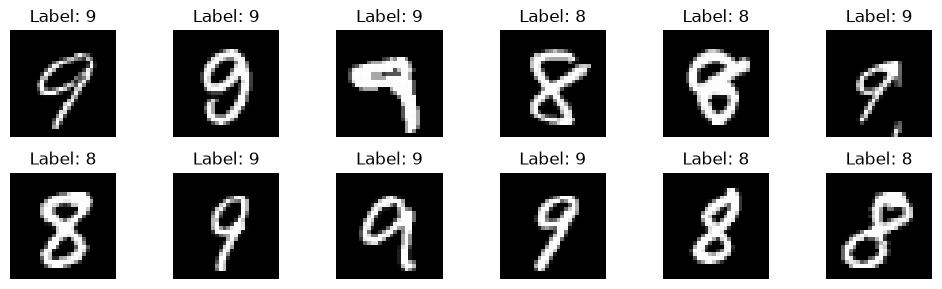

In [141]:
def show_images(images, labels=None, n=12):
    plt.figure(figsize=(10, 3))
    for i in range(min(n, images.shape[0])):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i, :, :, 0] * 127.5 + 127.5, cmap="gray")
        if labels is not None:
            plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_images, train_labels, n=12)


We now create a TensorFlow dataset. The dataset object handles shuffling and mini-batching during training.

* `BUFFER_SIZE` controls how many examples are used in the shuffle buffer.
* `BATCH_SIZE` controls how many images are processed before the network weights are updated.

For this small demonstration, both values are deliberately small.


In [142]:
BUFFER_SIZE = N_SAMPLES
BATCH_SIZE = 25

train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE, seed=SEED)
    .batch(BATCH_SIZE)
)


## 3. Build the generator

The generator receives a random vector, often called a **latent vector** or **noise vector**, and transforms it into an image.

In this notebook, the generator uses the following sequence:

1. a dense layer that expands the 100-dimensional noise vector;
2. a reshape operation to create a small 7 × 7 feature map;
3. transposed-convolution layers to upsample the feature map;
4. a final `tanh` layer that produces a 28 × 28 greyscale image.

A transposed convolution is a learnable upsampling operation. It is commonly used in image generators and decoders.


In [143]:
def make_generator_model(noise_dim=100):
    model = tf.keras.Sequential(name="generator")

    # Start from a random vector and project it into a low-resolution feature map.
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Reshape the vector into a 7 x 7 feature map with 256 channels.
    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)

    # Keep spatial size at 7 x 7, but reduce the number of channels.
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 7, 7, 128)

    # Upsample from 7 x 7 to 14 x 14.
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 14, 14, 64)

    # Upsample from 14 x 14 to 28 x 28 and produce one greyscale channel.
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"))
    assert model.output_shape == (None, 28, 28, 1)

    return model


We instantiate the generator and inspect its architecture. Notice that the generator has no image input. It only receives random noise.

**Question:** Why does the generator need random noise as input?


In [144]:
noise_dim = 100

generator = make_generator_model(noise_dim=noise_dim)
generator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Before training, the generator produces only noise-like images. This is expected because its weights are still random.


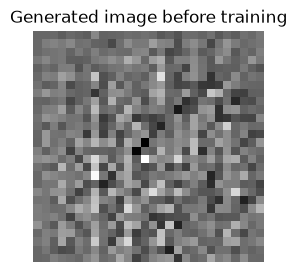

In [145]:
noise = tf.random.normal([1, noise_dim])
generated_image = generator(noise, training=False)

plt.figure(figsize=(3, 3))
plt.imshow(generated_image[0, :, :, 0] * 127.5 + 127.5, cmap="gray")
plt.title("Generated image before training")
plt.axis("off")
plt.show()


## 4. Build the discriminator

The discriminator is a binary classifier. It receives an image and returns a single score indicating whether the image looks real or fake.

The discriminator uses convolutional layers because the input is an image. The final dense layer has one output unit. This output is a **logit**, not a probability. A logit is a raw score before applying a sigmoid transformation.


In [146]:
def make_discriminator_model():
    model = tf.keras.Sequential(name="discriminator")

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same", input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


In [147]:
discriminator = make_discriminator_model()
discriminator.summary()


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Let us ask the untrained discriminator to score the image produced by the untrained generator. The value is not meaningful yet, but it confirms that the generator and discriminator can be connected.


In [148]:
decision = discriminator(generated_image)
print("Discriminator score for generated image:", decision.numpy())


Discriminator score for generated image: [[-0.00022922]]


## 5. Define the losses and optimisers

GANs have two losses:

* the **discriminator loss**, which measures how well the discriminator separates real images from fake images;
* the **generator loss**, which measures how successfully the generator fools the discriminator.

We use binary cross-entropy because the discriminator is solving a binary classification problem: real versus fake.

The argument `from_logits=True` is used because the discriminator returns raw logits rather than sigmoid probabilities.


In [149]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


The discriminator receives two kinds of examples:

* real MNIST images, which should be classified as `1`;
* fake generated images, which should be classified as `0`.

The total discriminator loss is the sum of the loss on real images and the loss on fake images.


In [150]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss


The generator wants the discriminator to classify fake images as real. Therefore, the generator loss compares the discriminator's prediction for fake images against the target value `1`.

**Question:** Why does the generator use labels equal to `1` for fake images when computing its own loss?


In [151]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)


We use separate Adam optimisers for the generator and discriminator. They are trained together, but each network has its own parameters and optimiser state.


In [152]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)


## 6. Optional checkpointing

Checkpoints allow us to save the state of the generator, discriminator and optimisers. This is useful when training takes a long time or when training is interrupted.

For the short practical session, checkpointing is not essential, but it is good practice to know how it works.


In [153]:
checkpoint_dir = "./training_checkpoints"
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator,
)


## 7. Define helper functions for visualisation

We use the same random seed images throughout training. This makes it easier to observe how the generator changes over time, because the input noise vectors remain fixed.


In [154]:
num_examples_to_generate = 16
fixed_seed = tf.random.normal([num_examples_to_generate, noise_dim])


The next function generates a 4 × 4 grid of images and saves it to disk. The saved images can later be combined into a GIF to show training progress.


In [155]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.savefig(f"image_at_epoch_{epoch:04d}.png")
    plt.show()


## 8. Define the training step

The function below performs one training step for one mini-batch.

The core idea is:

1. sample random noise;
2. use the generator to create fake images;
3. use the discriminator to score real and fake images;
4. compute the generator and discriminator losses;
5. compute gradients;
6. update both sets of network weights.

`tf.GradientTape` records the operations needed to calculate gradients. This gives us more control than the usual `model.fit()` workflow.


In [156]:
@tf.function
def train_step(images):
    current_batch_size = tf.shape(images)[0]
    noise = tf.random.normal([current_batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


## 9. Define the training loop

The training loop applies `train_step()` to every batch in the dataset for a selected number of epochs.

The original version of this notebook used many more epochs. For a live practical session, the default below is deliberately smaller. Increase it if you want better images and have enough time or GPU access.


In [157]:
EPOCHS = 5000
SAVE_EVERY = 25


In [158]:
def train(dataset, epochs):
    generator_losses = []
    discriminator_losses = []

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_losses.append(gen_loss.numpy())
            epoch_disc_losses.append(disc_loss.numpy())

        generator_losses.append(np.mean(epoch_gen_losses))
        discriminator_losses.append(np.mean(epoch_disc_losses))

        if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
            display.clear_output(wait=True)
            generate_and_save_images(generator, epoch + 1, fixed_seed)
            print(f"Epoch {epoch + 1}/{epochs}")
            print(f"Generator loss: {generator_losses[-1]:.4f}")
            print(f"Discriminator loss: {discriminator_losses[-1]:.4f}")
            print(f"Time for epoch: {time.time() - start:.2f} seconds")

        if (epoch + 1) % 100 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, fixed_seed)
    return generator_losses, discriminator_losses


## 10. Train the GAN

We can now train the generator and discriminator.

At the beginning, generated images will look like random noise. If training is successful, they should gradually begin to resemble the selected MNIST digits.

**Important:** GAN loss curves are not interpreted in the same way as ordinary supervised learning curves. A lower generator or discriminator loss does not always mean that the generated images are better. Visual inspection remains important in this introductory exercise.


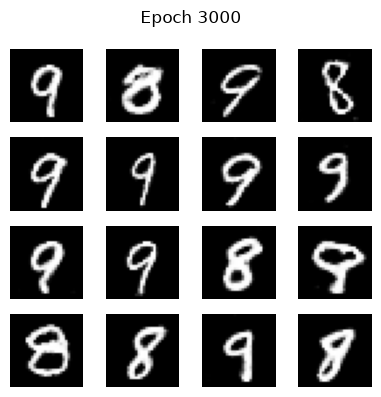

Epoch 3000/5000
Generator loss: 1.5637
Discriminator loss: 0.8985
Time for epoch: 0.33 seconds


In [ ]:
generator_losses, discriminator_losses = train(train_dataset, EPOCHS)


Let us plot the generator and discriminator losses. These curves are useful for checking whether one model is overpowering the other, but they should not be treated as a simple performance score.


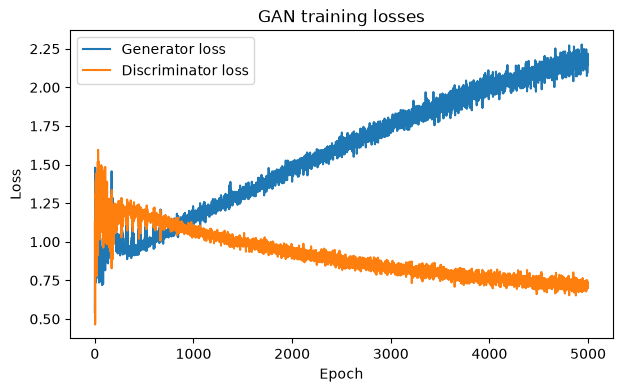

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(generator_losses, label="Generator loss")
plt.plot(discriminator_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN training losses")
plt.show()


## 11. Display generated images

The image below shows the generated samples from the final epoch.


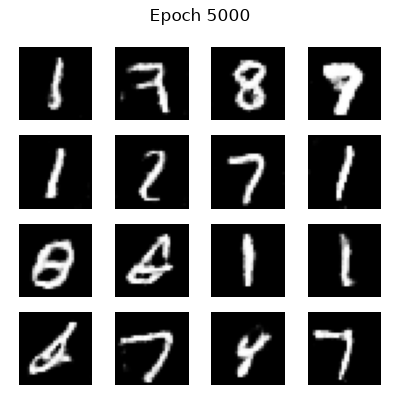

In [ ]:
def display_image(epoch_no):
    return PIL.Image.open(f"image_at_epoch_{epoch_no:04d}.png")

display_image(EPOCHS)


## 12. Optional: create an animation

The saved images can be combined into an animated GIF. This is a useful way to show how the generator evolves during training.


In [ ]:
image_files = sorted(glob.glob("image_at_epoch_*.png"))

if image_files:
    with imageio.get_writer("gan_training.gif", mode="I") as writer:
        for filename in image_files:
            image = imageio.imread(filename)
            writer.append_data(image)
    print("Saved animation as gan_training.gif")
else:
    print("No images found. Train the model first.")


/tmp/ipykernel_8737/3299291153.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


Saved animation as gan_training.gif


## 13. Exercises

### Exercise 1: Change the selected digits

Change:

```python
SELECTED_DIGITS = [0, 1, 2]
```

to another set of digits, for example `[3, 8]` or all ten digits. Re-run the notebook and compare the generated images.

**Question:** Does the generator find it easier to learn one digit class, a few digit classes, or all digit classes?

### Exercise 2: Increase the number of training images

Change:

```python
N_SAMPLES = 100
```

to a larger value such as `500` or `1000`.

**Question:** What changes in training time and image quality?

### Exercise 3: Increase the number of epochs

Change:

```python
EPOCHS = 300
```

to a larger value such as `1000`, if time permits.

**Question:** Do the images keep improving, or does training become unstable?

### Exercise 4: Modify the generator

Try changing the number of filters in one of the `Conv2DTranspose` layers.

**Question:** How does model capacity affect generated images and training speed?

### Exercise 5: Think critically about evaluation

GANs are difficult to evaluate.

**Question:** Why is visual inspection not enough for evaluating generative models in real applications, such as medical image generation?


## Summary

In this tutorial, we implemented a simple GAN for generating MNIST-like images. The key concepts were:

* the **generator** maps random noise to synthetic images;
* the **discriminator** classifies images as real or fake;
* both models are trained together in an adversarial loop;
* the generator improves by learning to fool the discriminator;
* the discriminator improves by learning to detect generated images;
* GAN training is more unstable than standard supervised learning and often requires careful tuning.

This tutorial connects to the lecture material on generative models and shows how transposed convolutions can be used inside a neural image generator.
